### Tasks

* 1. Load the Iris dataset using Python's sklearn, perform hierarchical clustering with the 'ward' linkage, and plot the resulting dendrogram using scipy's dendrogram() function.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [18]:
df = load_iris()
df = pd.DataFrame(df.data, columns=df.feature_names)

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked_ward = linkage(df.values, method="ward")

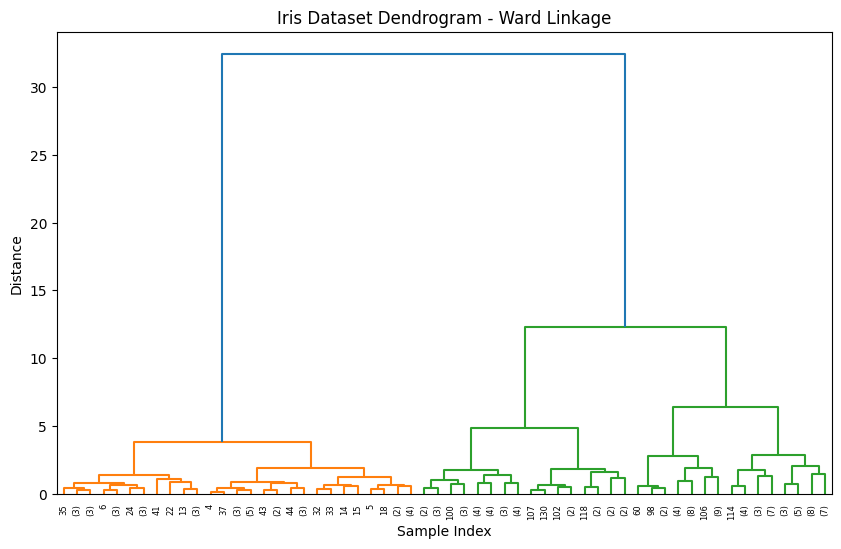

In [20]:
plt.figure(figsize=(10, 6))
dendrogram(linked_ward,truncate_mode='level', p=5,show_leaf_counts=True)
plt.title("Iris Dataset Dendrogram - Ward Linkage")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

* 2. Visually inspect the dendrogram you plotted and cut it at a height that results in 3 distinct clusters. Assign each data point to its cluster and print the number of samples in each cluster.<br><br><em><strong>Hint:</strong> Use scipy's fcluster() with the 'criterion' set to 'distance' and your chosen height.</em>

In [ ]:
from scipy.cluster.hierarchy import fcluster
clusters_ward = fcluster(linked_ward, t=10, criterion="distance")
cluster_counts = pd.Series(clusters_ward).value_counts()
cluster_counts

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [22]:
cluster_counts = pd.Series(clusters_ward).value_counts()
cluster_counts

3    64
1    50
2    36
Name: count, dtype: int64

* 3. Repeat the dendrogram plotting for the same data using 'single' and 'complete' linkage methods, and compare how the cluster shapes and heights differ from 'ward' linkage.<br><br><em><strong>Hint:</strong> Place all three dendrograms side by side for visual comparison.</em>

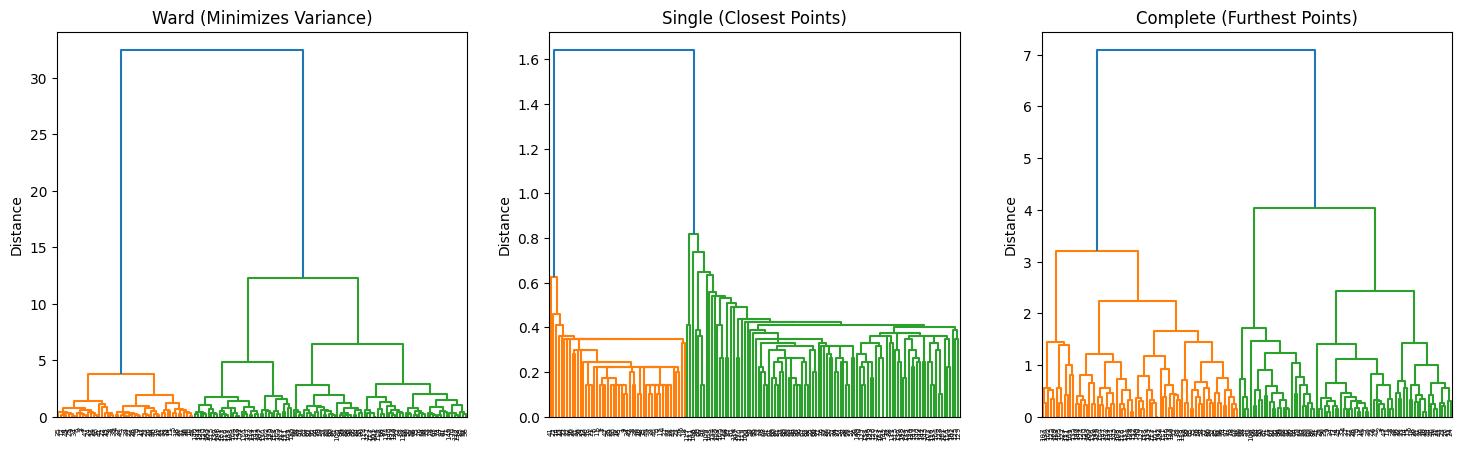

In [25]:
linked_single = linkage(df.values, method="single")
linked_complete = linkage(df.values, method="complete")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dendrogram(linked_ward, ax=axes[0])
axes[0].set_title("Ward (Minimizes Variance)")
axes[0].set_ylabel("Distance")

dendrogram(linked_single, ax=axes[1])
axes[1].set_title("Single (Closest Points)")
axes[1].set_ylabel("Distance")

dendrogram(linked_complete, ax=axes[2])
axes[2].set_title("Complete (Furthest Points)")
axes[2].set_ylabel("Distance")

plt.show()

* 4. Interpret the dendrogram you created: Write a short explanation (3-4 lines) describing how you can tell which clusters are most similar and which are most different, based on the heights and structure of the branches.

Here is a short, punchy breakdown of how to read the branch heights:

### Reading the Vertical Height (y-axis)

* **Low Merges (Short Branches):** Points or clusters are **highly similar** and closely related.
* **High Merges (Long Branches):** Clusters are **highly dissimilar** and represent distinct groups.

**In short:** The lower the merge, the closer the relationship. The higher the merge, the bigger the difference.